In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d uciml/iris

Dataset URL: https://www.kaggle.com/datasets/uciml/iris
License(s): CC0-1.0
  0% 0.00/3.60k [00:00<?, ?B/s]
100% 3.60k/3.60k [00:00<00:00, 7.80MB/s]


In [ ]:
!unzip -q /content/iris.zip

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df=pd.read_csv('Iris.csv')

In [ ]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
df.dtypes

,0
Id,int64
SepalLengthCm,float64
SepalWidthCm,float64
PetalLengthCm,float64
PetalWidthCm,float64
Species,object


In [ ]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
df.duplicated().sum()

0

In [ ]:
df.shape

(150, 6)

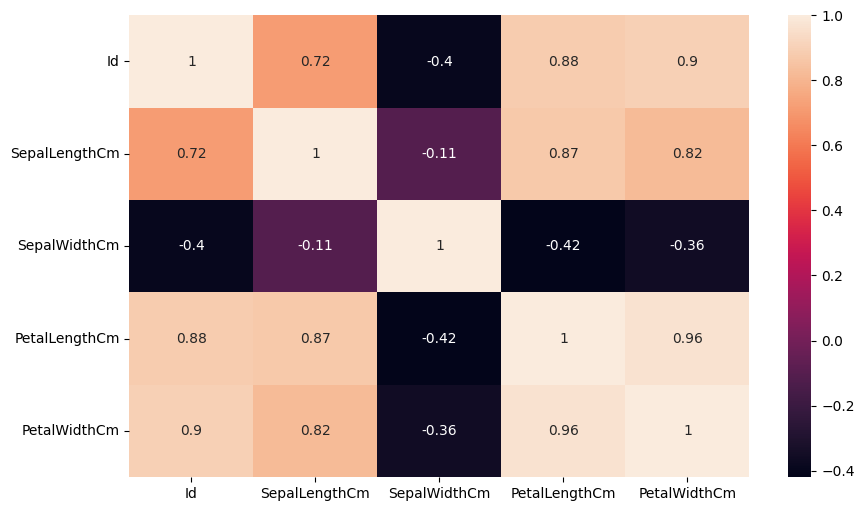

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [ ]:
df.Species.value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


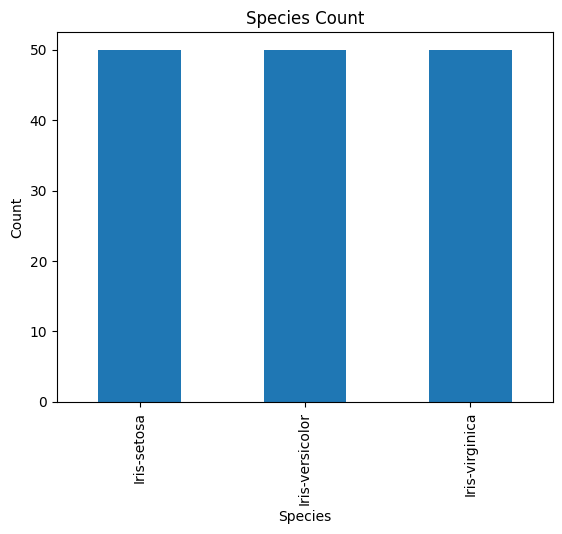

In [ ]:
df.Species.value_counts().plot(kind='bar')
plt.title('Species Count')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Species']=le.fit_transform(df['Species'])
df.Species.value_counts()

,count
Species,
0,50
1,50
2,50


In [ ]:
df.drop('Id',axis=1,inplace=True)

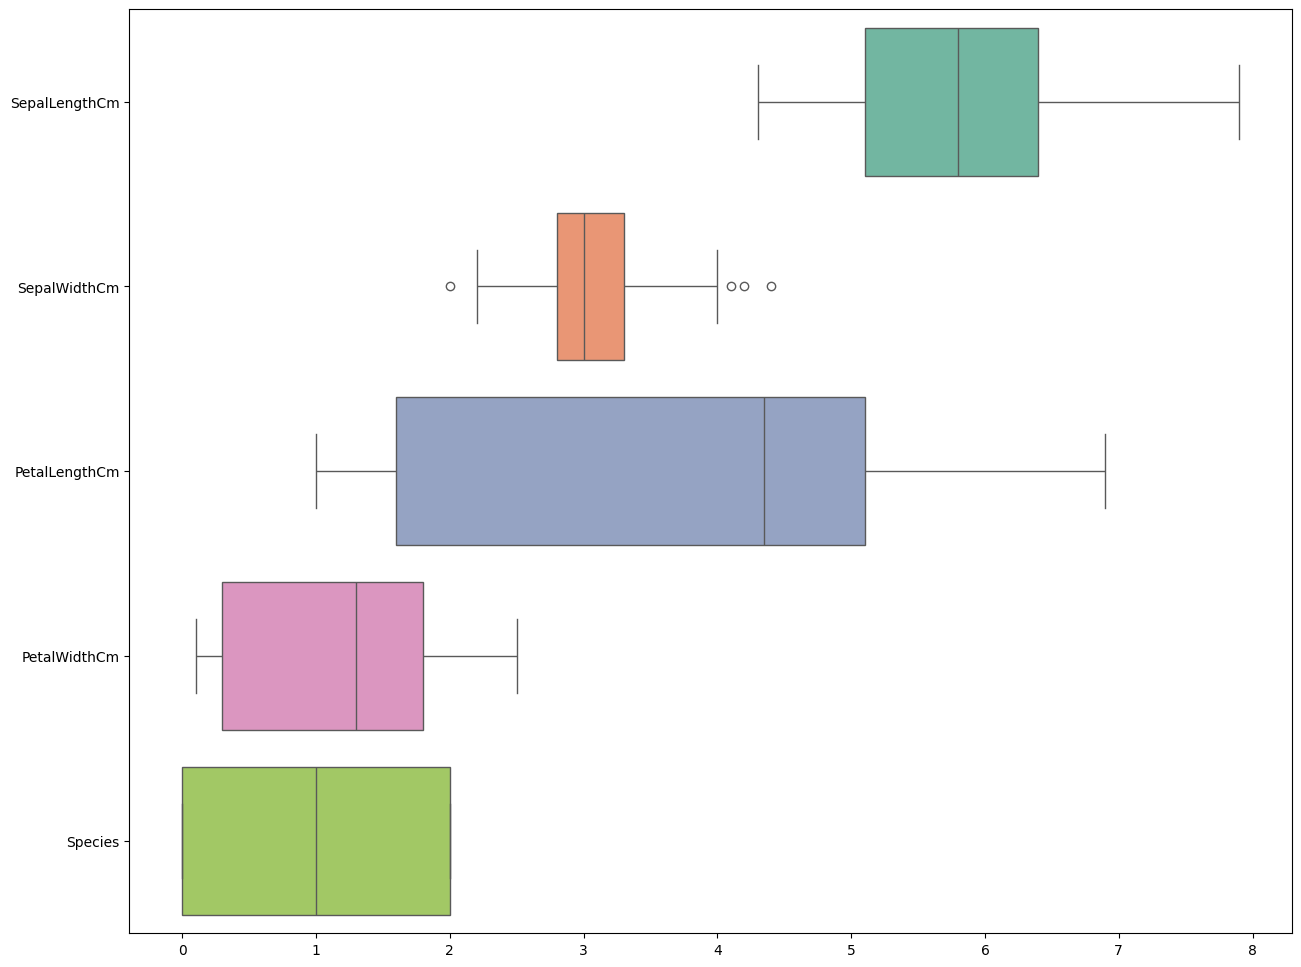

In [ ]:
#check outliers
numerical_col=df.select_dtypes(include=["int64","float64"]).columns
plt.figure(figsize=(15,12))
sns.boxplot(data=df[numerical_col],orient="h",palette="Set2")
plt.show()

In [ ]:
def handle_outliers(df,column):
  Q1=df[column].quantile(0.25)
  Q3=df[column].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR

  df[column]=np.where(df[column]>upper_bound,upper_bound,df[column])
  df[column]=np.where(df[column]<lower_bound,lower_bound,df[column])
  return df

numerical_col=df.select_dtypes(include=["int64","float64"]).columns
for col in numerical_col:
  df=handle_outliers(df,col)

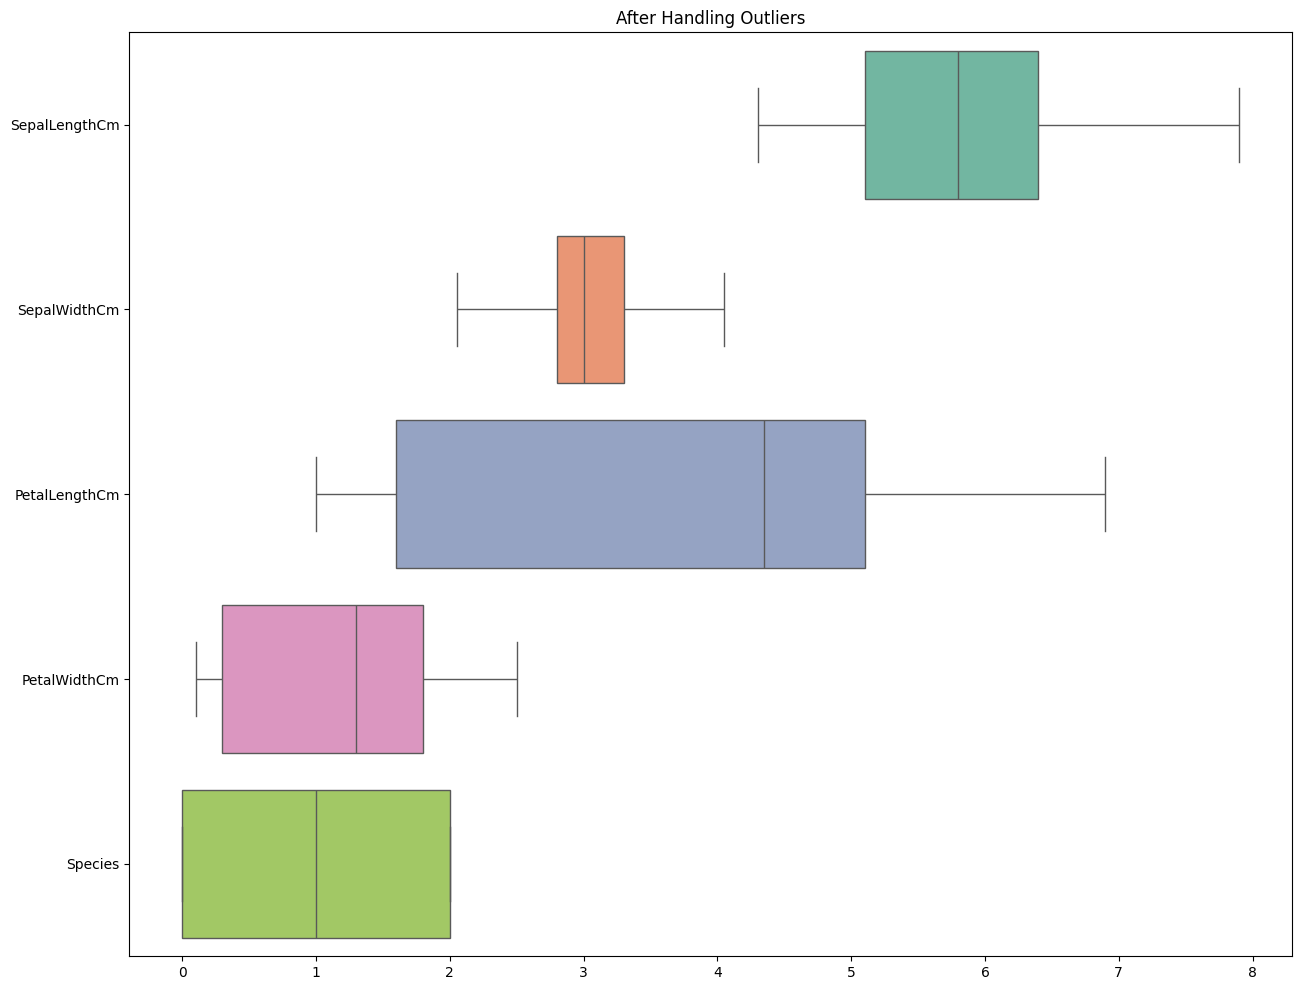

In [ ]:
numerical_col=df.select_dtypes(include=["int64","float64"]).columns
plt.figure(figsize=(15,12))
sns.boxplot(data=df[numerical_col],orient="h",palette="Set2")
plt.title("After Handling Outliers")
plt.show()

In [ ]:
x=df.drop('Species',axis=1)
y=df['Species']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)

In [ ]:
model=LogisticRegression(multi_class='multinomial')

In [ ]:
model.fit(x_train,y_train)

LogisticRegression(multi_class='multinomial')

In [ ]:
y_pred=model.predict(x_test)

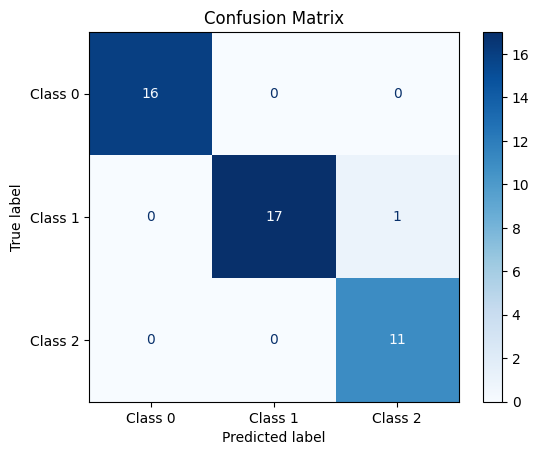

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,y_pred)


n_classes = cm.shape[0]


display_labels = [f'Class {i}' for i in range(n_classes)]

dis_cm=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
dis_cm.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        16
         1.0       1.00      0.94      0.97        18
         2.0       0.92      1.00      0.96        11

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [ ]:
model.score(x_test, y_test)*100

97.77777777777777

In [ ]:
from sklearn.preprocessing import StandardScaler
sc_x=StandardScaler()
x_train=sc_x.fit_transform(x_train)
x_test=sc_x.transform(x_test)

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf', 'poly']}


classifier = SVC(random_state=0)


grid_model = GridSearchCV(classifier, param_grid)


grid_model.fit(x_train, y_train)

GridSearchCV(estimator=SVC(random_state=0),
             param_grid={'C': [0.1, 1, 10],
                         'kernel': ['linear', 'rbf', 'poly']})

In [ ]:
y_pred = grid_model.predict(x_test)
y_pred

array([2., 1., 0., 2., 0., 2., 0., 1., 1., 1., 2., 1., 1., 1., 1., 0., 1.,
       1., 0., 0., 2., 1., 0., 0., 2., 0., 0., 1., 1., 0., 2., 1., 0., 2.,
       2., 1., 0., 2., 1., 1., 2., 0., 2., 0., 0.])

In [ ]:
best_params = grid_model.best_params_
print("Best parameters:", best_params)

Best parameters: {'C': 1, 'kernel': 'rbf'}


In [ ]:
from sklearn.svm import SVC
classifier=SVC(C=1,kernel='rbf',random_state=0)
classifier.fit(x_train,y_train)

SVC(C=1, random_state=0)

In [ ]:
y_pred=classifier.predict(x_test)
y_pred

array([2., 1., 0., 2., 0., 2., 0., 1., 1., 1., 2., 1., 1., 1., 1., 0., 1.,
       1., 0., 0., 2., 1., 0., 0., 2., 0., 0., 1., 1., 0., 2., 1., 0., 2.,
       2., 1., 0., 2., 1., 1., 2., 0., 2., 0., 0.])

In [ ]:
y_test.values

array([2., 1., 0., 2., 0., 2., 0., 1., 1., 1., 2., 1., 1., 1., 1., 0., 1.,
       1., 0., 0., 2., 1., 0., 0., 2., 0., 0., 1., 1., 0., 2., 1., 0., 2.,
       2., 1., 0., 1., 1., 1., 2., 0., 2., 0., 0.])

In [ ]:
#score
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9777777777777777

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        16
         1.0       1.00      0.94      0.97        18
         2.0       0.92      1.00      0.96        11

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
param_grid={'criterion':['gini','entropy'],'max_depth':[4,5,6,7,8,9,10,11,12,15,20,30,40,50,70,90,120,150]}
dtc=DecisionTreeClassifier()
grid_search=GridSearchCV(estimator=dtc,param_grid=param_grid,cv=10)
grid_search.fit(x_train,y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 20, 30,
                                       40, 50, 70, 90, 120, 150]})

In [ ]:
grid_search.best_params_

{'criterion': 'gini', 'max_depth': 6}

In [ ]:
dtc = DecisionTreeClassifier(criterion='gini',max_depth=6,random_state=0)
dtc.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=6, random_state=0)

In [ ]:
dtc_score_train = dtc.score(x_test,y_test)
print('Accuracy: ', dtc_score_train)

Accuracy:  0.9777777777777777


In [ ]:
predict_test = dtc.predict(x_test)
print(classification_report(y_test,predict_test))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        16
         1.0       1.00      0.94      0.97        18
         2.0       0.92      1.00      0.96        11

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



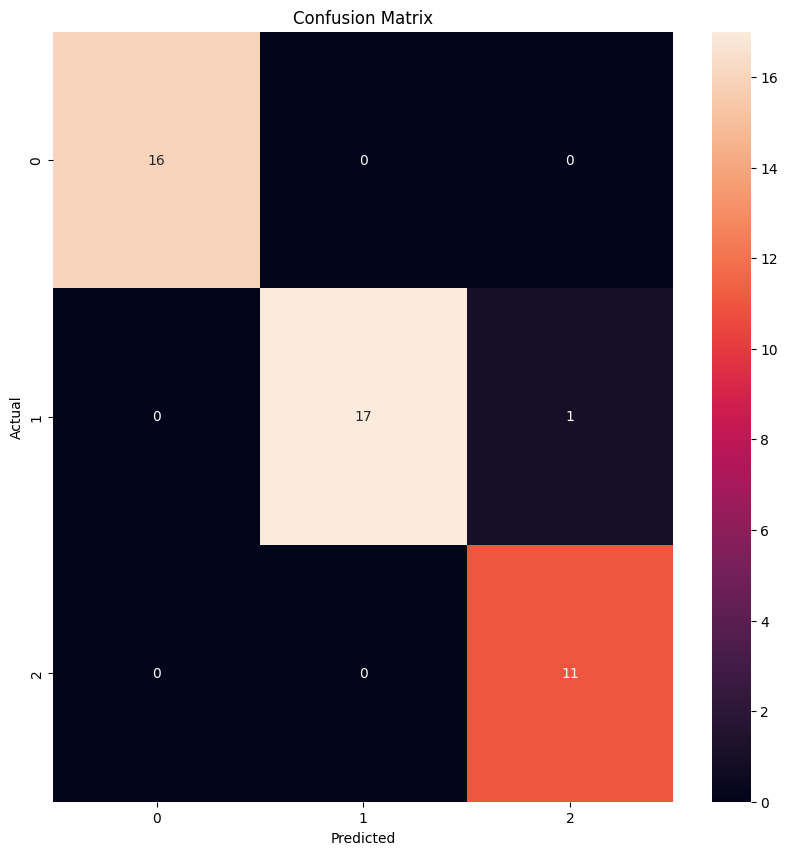

In [ ]:
plt.figure(figsize=(10,10))
cm = confusion_matrix(y_test, predict_test)
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


[Text(0.4, 0.9, 'PetalWidthCm <= -0.613\ngini = 0.664\nsamples = 105\nvalue = [34, 32, 39]'),
 Text(0.3, 0.7, 'gini = 0.0\nsamples = 34\nvalue = [34, 0, 0]'),
 Text(0.5, 0.7, 'PetalLengthCm <= 0.624\ngini = 0.495\nsamples = 71\nvalue = [0, 32, 39]'),
 Text(0.2, 0.5, 'PetalWidthCm <= 0.544\ngini = 0.161\nsamples = 34\nvalue = [0, 31, 3]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 30\nvalue = [0, 30, 0]'),
 Text(0.3, 0.3, 'SepalWidthCm <= 0.137\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.8, 0.5, 'PetalWidthCm <= 0.673\ngini = 0.053\nsamples = 37\nvalue = [0, 1, 36]'),
 Text(0.7, 0.3, 'PetalWidthCm <= 0.544\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.9, 0.3, 'gini = 0.0\nsamples = 33\nvalue = [0, 0, 33]')]

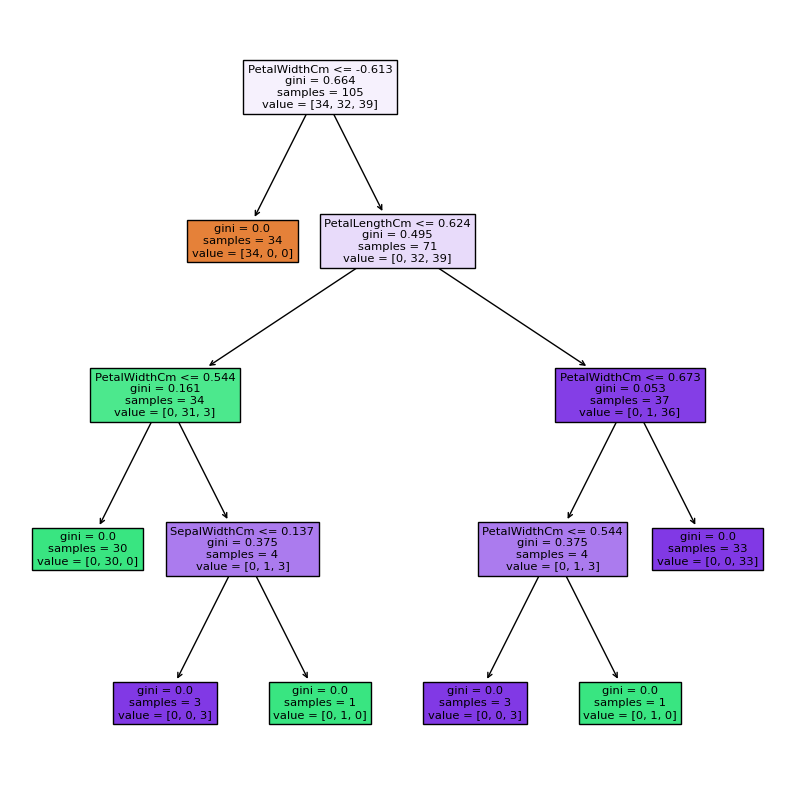

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(dtc,filled=True, feature_names=['SepalLengthCm',
                                               'SepalWidthCm',
                                               'PetalLengthCm',
                                               'PetalWidthCm'])

In [ ]:
#random forest tree
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    'n_estimators': [200, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['gini', 'entropy']
}
rfc=RandomForestClassifier()
CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv= 5)
CV_rfc.fit(x_train, y_train)


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
100 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 638, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/util

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 5, 6, 7, 8],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [200, 500]})

In [ ]:
CV_rfc.best_params_

{'criterion': 'gini',
 'max_depth': 4,
 'max_features': 'sqrt',
 'n_estimators': 200}

In [ ]:
rfc=RandomForestClassifier(criterion='gini',max_depth=4,max_features='sqrt',n_estimators=200)
rfc.fit(x_train,y_train)

RandomForestClassifier(max_depth=4, n_estimators=200)

In [ ]:
y_pred=rfc.predict(x_test)
y_pred

array([2., 1., 0., 2., 0., 2., 0., 1., 1., 1., 2., 1., 1., 1., 1., 0., 1.,
       1., 0., 0., 2., 1., 0., 0., 2., 0., 0., 1., 1., 0., 2., 1., 0., 2.,
       2., 1., 0., 2., 1., 1., 2., 0., 2., 0., 0.])

In [ ]:
print("Accuracy for Random Forest on CV data: ",accuracy_score(y_test,y_pred))

Accuracy for Random Forest on CV data:  0.9777777777777777


In [ ]:
#xgboost
from xgboost import XGBClassifier
params = {
        'min_child_weight': [1, 5, 10],
        'gamma': [0.5, 1, 1.5, 2, 5],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'max_depth': [3, 4, 5]
        }
grid_xg=GridSearchCV(XGBClassifier(),param_grid=params,cv=5,n_jobs=-1,verbose=3)
grid_xg.fit(x_train,y_train)

Fitting 5 folds for each of 405 candidates, totalling 2025 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'gamma': [0.5, 1, 1.5, 2, 5], 'max_depth': [3, 4, 5],
                         'min_child_weight': [1, 5, 10],
                         'subsample': [0.6, 0.8, 1.0]},
             verbose=3)

In [ ]:
grid_xg.best_params_

{'colsample_bytree': 0.6,
 'gamma': 0.5,
 'max_depth': 3,
 'min_child_weight': 1,
 'subsample': 0.8}

In [ ]:
xgb=XGBClassifier(colsample_bytree=0.6,gamma=0.5,max_depth=3,min_child_weight=1,subsample=0.8)
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.5, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
y_pred=xgb.predict(x_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0, 2, 1, 0, 2, 2, 1, 0, 2, 1, 1, 2, 0, 2, 0,
       0])

In [ ]:
print("Accuracy for Random Forest on CV data: ",accuracy_score(y_test,y_pred))

Accuracy for Random Forest on CV data:  0.9777777777777777


In [ ]:
X=df.drop('Species',axis=1)
y=df['Species']

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical

In [ ]:
df['Species'] = pd.Categorical(df.Species)
df['Species'] = df.Species.cat.codes
# Turn response variable into one-hot response vectory = to_categorical(df.response)
y = to_categorical(df.Species)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,stratify=y,random_state=123)


In [ ]:
model=Sequential()
model.add(Dense(100,activation='relu',input_shape=(4,)))

model.add(Dense(3,activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(X_train,y_train,epochs=45,validation_data=(X_test, y_test))

Epoch 1/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.3313 - loss: 1.6750 - val_accuracy: 0.3333 - val_loss: 1.4372
Epoch 2/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3219 - loss: 1.4009 - val_accuracy: 0.3333 - val_loss: 1.1925
Epoch 3/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3333 - loss: 1.1432 - val_accuracy: 0.3333 - val_loss: 1.0342
Epoch 4/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3073 - loss: 1.0424 - val_accuracy: 0.3556 - val_loss: 0.9545
Epoch 5/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3805 - loss: 0.9570 - val_accuracy: 0.5556 - val_loss: 0.9169
Epoch 6/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4963 - loss: 0.9291 - val_accuracy: 0.4889 - val_loss: 0.8808
Epoch 7/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4356 - loss: 0.8829 - val_accuracy: 0.5778 - val_loss: 0.8372
Epoch 8/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6812 - loss: 0.8441 - val_accuracy: 0.9111 - val_loss: 0.7991

In [ ]:
model.evaluate(X_test,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9347 - loss: 0.3779


[0.38199976086616516, 0.9333333373069763]

In [ ]:
pred = model.predict(X_test[:10])
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[0.0169292  0.37377492 0.6092959 ]
 [0.87081337 0.11395445 0.0152322 ]
 [0.07829096 0.53431875 0.3873903 ]
 [0.0464016  0.54201764 0.4115808 ]
 [0.92944837 0.06423321 0.00631846]
 [0.00495485 0.3006086  0.6944366 ]
 [0.01932987 0.40001807 0.58065206]
 [0.01894406 0.3743407  0.60671526]
 [0.00492153 0.26474518 0.73033327]
 [0.00500419 0.24144106 0.7535547 ]]


In [ ]:
p=np.argmax(pred,axis=1)
print(p)
print(y_test[:10])

[2 0 1 1 0 2 2 2 2 2]
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [ ]:
history.history['accuracy']

[0.3333333432674408,
 0.3333333432674408,
 0.3333333432674408,
 0.3333333432674408,
 0.4095238149166107,
 0.5142857432365417,
 0.46666666865348816,
 0.723809540271759,
 0.9142857193946838,
 0.8571428656578064,
 0.7047619223594666,
 0.6666666865348816,
 0.6666666865348816,
 0.6666666865348816,
 0.6666666865348816,
 0.6857143044471741,
 0.761904776096344,
 0.8857142925262451,
 0.961904764175415,
 0.961904764175415,
 0.961904764175415,
 0.9142857193946838,
 0.8476190567016602,
 0.8190476298332214,
 0.7904762029647827,
 0.8190476298332214,
 0.8476190567016602,
 0.8476190567016602,
 0.9047619104385376,
 0.9333333373069763,
 0.9428571462631226,
 0.9428571462631226,
 0.9047619104385376,
 0.8761904835700989,
 0.9142857193946838,
 0.961904764175415,
 0.961904764175415,
 0.9809523820877075,
 0.9904761910438538,
 0.9904761910438538,
 0.9714285731315613,
 0.961904764175415,
 0.9428571462631226,
 0.9333333373069763,
 0.9333333373069763]

In [ ]:
history.history['val_accuracy']

[0.3333333432674408,
 0.3333333432674408,
 0.3333333432674408,
 0.35555556416511536,
 0.5555555820465088,
 0.4888888895511627,
 0.5777778029441833,
 0.9111111164093018,
 0.8888888955116272,
 0.7555555701255798,
 0.6888889074325562,
 0.6666666865348816,
 0.6666666865348816,
 0.6666666865348816,
 0.6888889074325562,
 0.7333333492279053,
 0.8444444537162781,
 0.9111111164093018,
 0.9333333373069763,
 0.9333333373069763,
 0.9111111164093018,
 0.8444444537162781,
 0.7777777910232544,
 0.7777777910232544,
 0.7777777910232544,
 0.8222222328186035,
 0.8444444537162781,
 0.8666666746139526,
 0.9111111164093018,
 0.9111111164093018,
 0.9111111164093018,
 0.8888888955116272,
 0.8666666746139526,
 0.8666666746139526,
 0.9111111164093018,
 0.9333333373069763,
 0.9333333373069763,
 0.9333333373069763,
 0.9333333373069763,
 0.9333333373069763,
 0.9333333373069763,
 0.9333333373069763,
 0.8888888955116272,
 0.8888888955116272,
 0.9333333373069763]

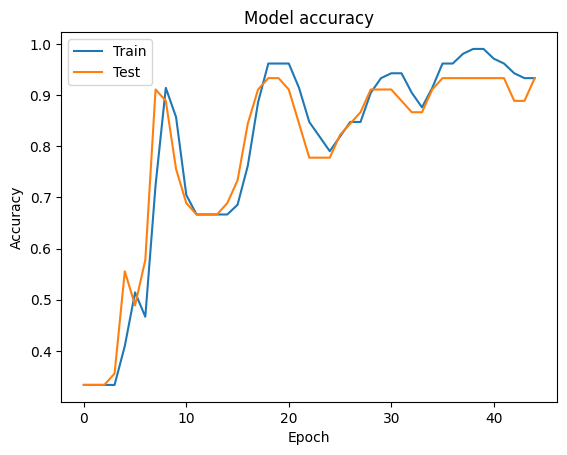

In [ ]:
plt.figure()


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'])
plt.show()